# Comparative analysis per location / site

This notebook compiles descriptive statistics and visualisations for **specific electrical conductivity (SEC)** profiles collected in the priority wells AW5, AW6, BW3, LRS69 and LRS70 on Andros Island (Bahamas).

Steps performed:

1. **Load & harmonise raw CSV files** (and the SOLINST summary file).
2. **Parse metadata** from each filename.
3. **Compute descriptive statistics** for every well log.
4. **Assemble a tidy statistics table** for subsequent analysis.
5. **Draw publication-quality box-plots** (or mean ± SD bands for SOLINST) for every priority site.

In [1]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110})

---

### Constants and helper dictionaries


In [2]:
ROOT = Path(os.path.abspath('../..'))
RAW_FOLDER = ROOT / "data" / "raw"
PRIORITY_SITES = {"AW5", "AW6", "BW3", "LRS69", "LRS70"}

DEFAULT_COLUMN_MAPPINGS = {
    "depth": [
        "Vertical Position [m]",
        "Vertical Position m"
    ],
    "conductivity": [
        "Corrected sp Cond [uS/cm]",
        "Corrected sp Cond [µS/cm]"
    ]
}

DEFAULT_COLUMN_MAPPINGS_2025 = {
    "depth": [
        "Vertical Position [m]",
        "Vertical Position m"
    ],
    "conductivity": [
        "SpCond_muS/cm",
        "SpCond µS/cm"
    ]
}

# Outlier detection multiplier
IQR_FACTOR = 1.5

---

### 2. Helper functions

In [3]:
def parse_filename(fname: str) -> dict:
    """Extract well-log metadata from filename using the agreed convention."""
    fname = Path(fname).stem  # drop .csv
    pattern = (
        r"(?P<id>[A-Z]+[0-9]+)_(?P<well_type>[DSO])"  # mandatory parts
        r"(?:_(?P<variant>[0-9]+))?"                  # optional numeric variant
        r"_(?P<instrument>[A-Za-z]+)"                # instrument
        r"(?:_(?P<probe_type>[A-Za-z]))?"            # optional probe type
        r"_(?P<date>\d{8})"                         # YYYYMMDD
        r"(?:_(?P<frequency>[^_]+))?"                # optional frequency (until .csv)
    )
    match = re.fullmatch(pattern, fname)
    if not match:
        warnings.warn(f"Filename '{fname}' does not match the expected schema; metadata set to NaN.")
        return {k: np.nan for k in [
            "id", "well_type", "variant", "instrument",
            "probe_type", "date", "frequency"
        ]}
    groups = match.groupdict()
    # Ensure all keys exist and convert blanks to NaN
    return {k: (v if v not in (None, "") else np.nan) for k, v in groups.items()}

In [4]:
def load_sec_profile(path: Path) -> pd.Series:
    """Return SEC column as numeric Series after applying the correct column mapping."""
    df = pd.read_csv(path)
    fname_meta = parse_filename(path.name)
    year = int(str(fname_meta.get("date", "0"))[:4]) if pd.notna(fname_meta.get("date")) else None
    mapping = DEFAULT_COLUMN_MAPPINGS_2025 if year == 2025 else DEFAULT_COLUMN_MAPPINGS

    # Find conductivity column
    conductivity_col = None
    for col in mapping["conductivity"]:
        if col in df.columns:
            conductivity_col = col
            break
    if conductivity_col is None:
        raise KeyError(f"No recognised conductivity column found in '{path.name}'.")

    sec = pd.to_numeric(df[conductivity_col], errors="coerce").dropna()
    return sec

---

### Assemble statistics for every priority CSV (plus SOLINST summary rows)

In [5]:
records = []           # list of dicts feeding the summary DataFrame
raw_data_cache = {}    # store SEC vectors for later box-plotting

# 1. Traverse raw sub-folders and load files that belong to priority sites
for sub in RAW_FOLDER.iterdir():
    if not sub.is_dir() or not sub.name.startswith("raw_"):
        continue
    for csv_file in sub.glob("*.csv"):
        meta = parse_filename(csv_file.name)
        if meta["id"] not in PRIORITY_SITES:
            continue
        try:
            sec = load_sec_profile(csv_file)
        except Exception as err:
            warnings.warn(f"Skipping '{csv_file.name}': {err}")
            continue

        stats = {
            **meta,
            "mean": sec.mean(),
            "std": sec.std(ddof=1),
            "cv": sec.std(ddof=1) / sec.mean() if sec.mean() else np.nan,
            "min": sec.min(),
            "max": sec.max(),
            "median": sec.median(),
            "p25": sec.quantile(0.25),
            "p50": sec.quantile(0.50),
            "p75": sec.quantile(0.75),
            "iqr": sec.quantile(0.75) - sec.quantile(0.25),
            "count": sec.size
        }
        # Detect outliers (1.5×IQR outside [Q1, Q3])
        q1, q3 = stats["p25"], stats["p75"]
        iqr = stats["iqr"]
        lower, upper = q1 - IQR_FACTOR * iqr, q3 + IQR_FACTOR * iqr
        stats["outliers"] = int(((sec < lower) | (sec > upper)).sum())

        records.append(stats)
        raw_data_cache[csv_file.stem] = sec

# 2. Incorporate SOLINST shallow-well summary rows
solinst_file = RAW_FOLDER / "solinst_shallow_wells.csv"
if solinst_file.exists():
    solinst_df = pd.read_csv(solinst_file)
    for _, row in solinst_df.iterrows():
        site = str(row["site_id"]).strip()
        if site not in PRIORITY_SITES:
            continue

        records.append({
            "id": site,
            "well_type": "S",           # shallow by definition
            "variant": np.nan,
            "instrument": "SOLINST",
            "probe_type": np.nan,
            "date": np.nan,
            "frequency": np.nan,
            "mean": row["mean_SpCond_uS/cm"],
            "std": row["standard_deviation"],
            "cv": row["standard_deviation"] / row["mean_SpCond_uS/cm"],
            "min": np.nan,
            "max": np.nan,
            "median": np.nan,
            "p25": np.nan,
            "p50": np.nan,
            "p75": np.nan,
            "iqr": np.nan,
            "count": 1,
            "outliers": 0
        })
else:
    warnings.warn("SOLINST summary file not found – skipping that dataset.")

# 3. Build DataFrame – enforce column order for clarity
cols_order = [
    "id", "well_type", "variant", "instrument", "probe_type", "date", "frequency",
    "mean", "std", "cv", "min", "max", "median", "p25", "p50", "p75", "iqr", "count", "outliers"
]
stats_df = pd.DataFrame(records)[cols_order]
display(stats_df)

C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\1139163443.py:14: UserWarning: Filename 'AW7_F_YSI_20220219' does not match the expected schema; metadata set to NaN.
  warnings.warn(f"Filename '{fname}' does not match the expected schema; metadata set to NaN.")
C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\1139163443.py:14: UserWarning: Filename 'Option1_D_YSI_20220201' does not match the expected schema; metadata set to NaN.
  warnings.warn(f"Filename '{fname}' does not match the expected schema; metadata set to NaN.")
C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\1139163443.py:14: UserWarning: Filename 'Option1_S_YSI_20220201' does not match the expected schema; metadata set to NaN.
  warnings.warn(f"Filename '{fname}' does not match the expected schema; metadata set to NaN.")
C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\1139163443.py:14: UserWarning: Filename 'AW7_D_a_YSI_20220820' does not match the expected schema; metadata set to NaN.
  warnings.warn(f"Filename '{f

,id,well_type,variant,instrument,probe_type,date,frequency,mean,std,cv,min,max,median,p25,p50,p75,iqr,count,outliers
0,AW5,D,NaN,YSI,NaN,20220213,NaN,10883.251138,15448.061102,1.419434,636.9,45571.4,674.9,655.0,674.9,15290.650,14635.650,7292,880
1,AW5,O,NaN,YSI,NaN,20220213,NaN,574.695988,7.858672,0.013674,566.2,620.8,573.0,571.8,573.0,574.900,3.100,3664,344
2,AW5,S,NaN,YSI,NaN,20220213,NaN,514.506808,3.414337,0.006636,510.8,524.1,513.4,511.4,513.4,516.925,5.525,852,0
3,AW6,D,NaN,YSI,NaN,20220219,NaN,7544.630765,10665.925952,1.413711,384.5,38008.2,1675.7,392.3,1675.7,13276.975,12884.675,6140,390
4,AW6,O,NaN,YSI,NaN,20220219,NaN,385.005363,8.837567,0.022954,369.4,397.1,383.1,377.5,383.1,394.800,17.300,1212,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,LRS70,D,NaN,YSI,R,20250226,NaN,21167.212776,20709.314555,0.978368,3259.2,54525.5,8178.3,4879.1,8178.3,51515.900,46636.800,16867,0
62,LRS70,S,NaN,YSI,R,20250226,NaN,3414.198786,3.942016,0.001155,3412.3,3444.4,3412.9,3412.7,3412.9,3413.600,0.900,412,46
63,BW3,S,NaN,SOLINST,NaN,NaN,NaN,446.000000,1.200000,0.002691,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
64,AW6,S,NaN,SOLINST,NaN,NaN,NaN,660.000000,1000.000000,1.515152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0


---

#### (Optional) Export the statistics table

In [9]:
stats_df.to_csv(f"{ROOT}/results/well_statistics.csv", index=False, encoding="utf-8")

---

### Box-plots (and SOLINST ±SD bands) by priority site

C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\4071204696.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


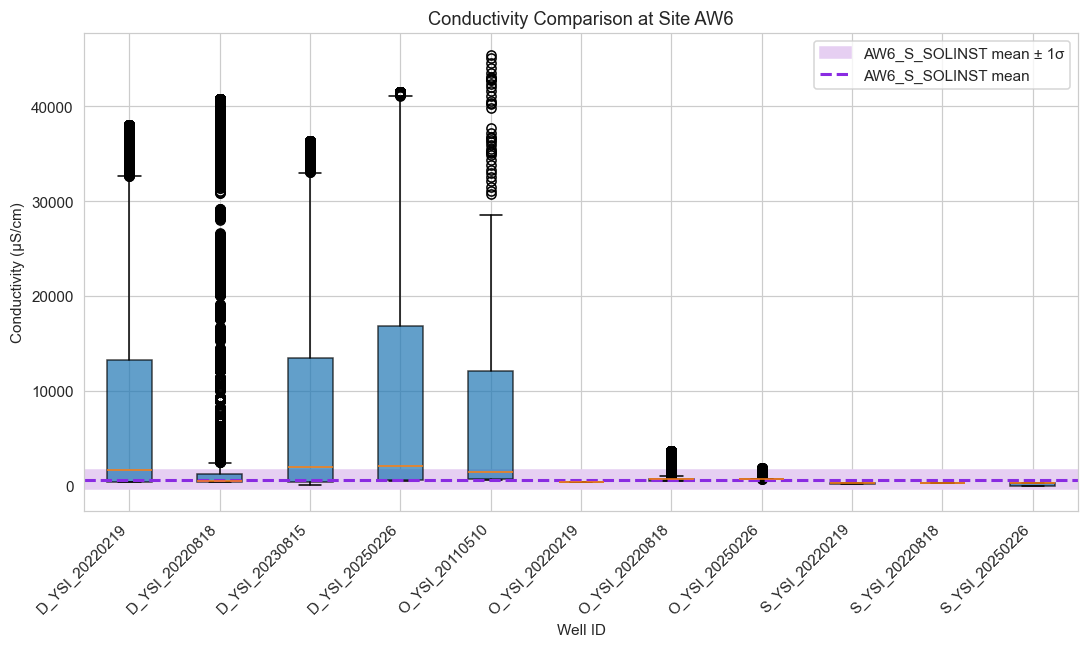

C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\4071204696.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


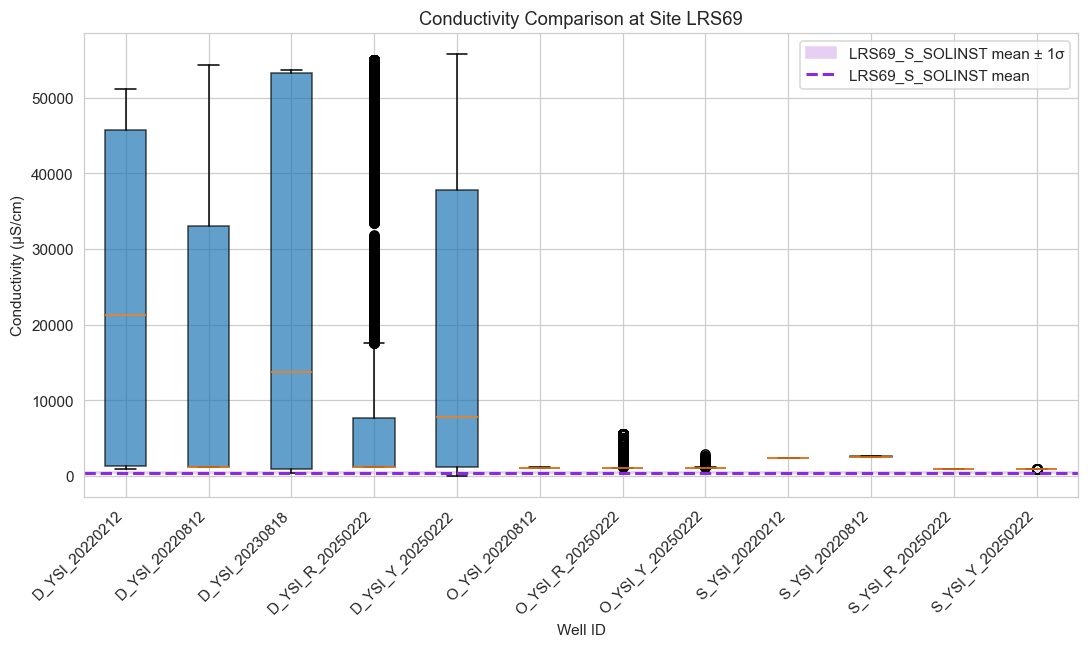

C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\4071204696.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


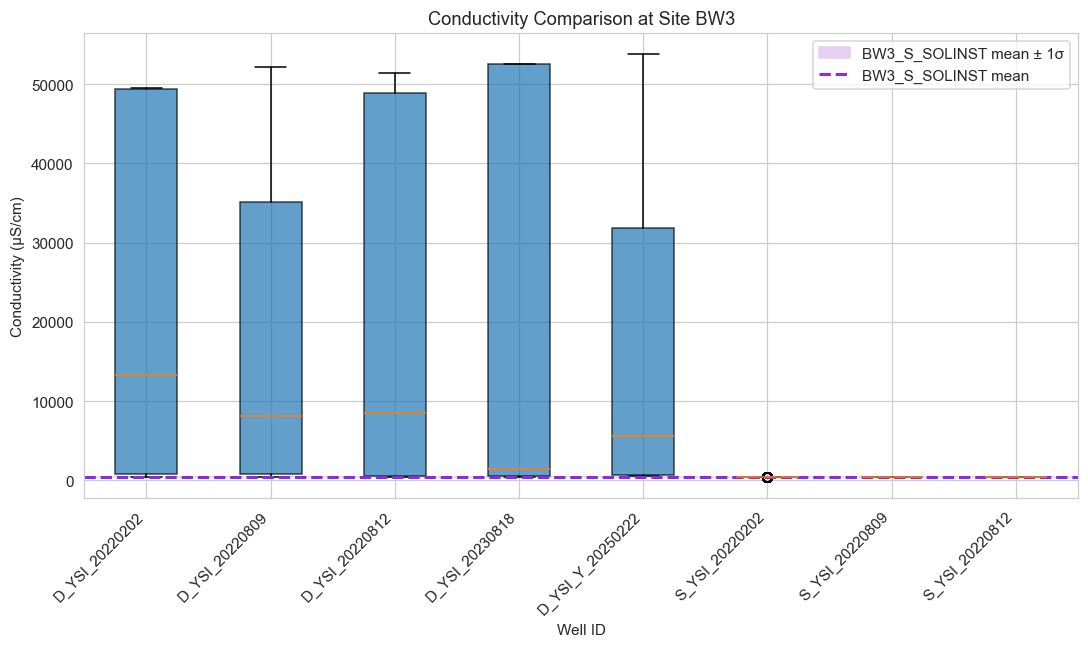

C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\4071204696.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\4071204696.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


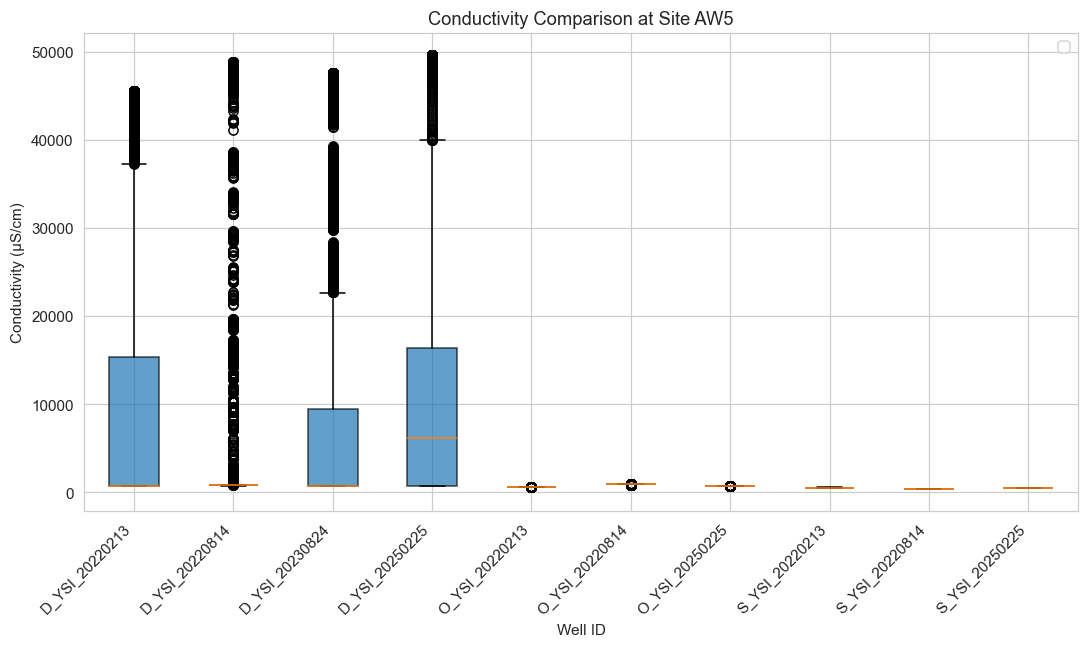

C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\4071204696.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\Arhui\AppData\Local\Temp\ipykernel_21664\4071204696.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


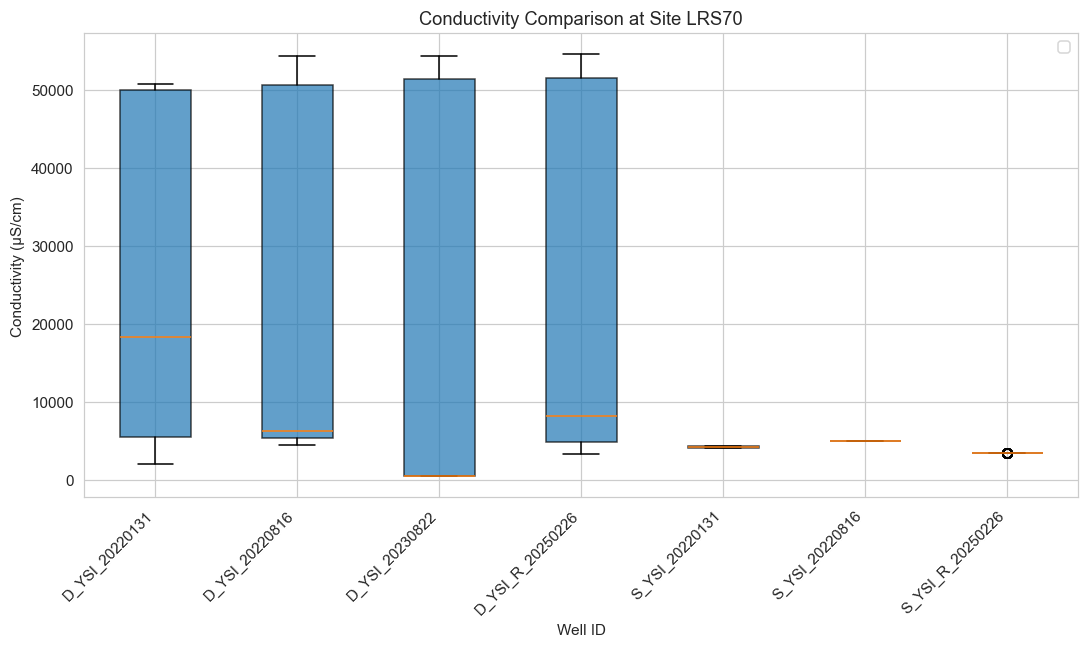

In [10]:
def nice_label(stem: str, site: str) -> str:
    """Remove the common site prefix (e.g. 'AW5_') and the date extension."""
    label = stem.replace(f"{site}_", "", 1)  # only first occurrence
    return label

for site in PRIORITY_SITES:
    fig, ax = plt.subplots(figsize=(10, 6))

    stems = [k for k in raw_data_cache.keys() if k.startswith(site)]
    stems_sorted = sorted(stems)
    data = [raw_data_cache[s] for s in stems_sorted]

    if data:
        bp = ax.boxplot(
            data,
            vert=True,
            patch_artist=True,
            labels=[nice_label(s, site) for s in stems_sorted]
        )
        for patch in bp['boxes']:
            patch.set_alpha(0.7)

    solinst_row = stats_df[(stats_df["id"] == site) & (stats_df["instrument"] == "SOLINST")]
    if not solinst_row.empty:
        mean_val = solinst_row.iloc[0]["mean"]
        sd_val = solinst_row.iloc[0]["std"]

        ax.axhspan(
            mean_val - sd_val,
            mean_val + sd_val,
            color="#E6CFF2",
            alpha=1.0,
            label=f"{site}_S_SOLINST mean ± 1σ"
        )

        ax.axhline(
            y=mean_val,
            color="#8A2BE2",
            linestyle="--",
            linewidth=2,
            label=f"{site}_S_SOLINST mean"
        )

    ax.set_title(f"Conductivity Comparison at Site {site}")
    ax.set_xlabel("Well ID")
    ax.set_ylabel("Conductivity (µS/cm)")
    plt.xticks(rotation=45, ha='right')
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

---

### (Optional) Interactive Boxplot

In [ ]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

def plot_site_boxplots(site: str, show_outliers: bool = True):
    """Renders interactive boxplots; each element can be hidden in the legend."""
    stems = sorted([k for k in raw_data_cache.keys() if k.startswith(site)])
    if not stems:
        print(f"No data found for site {site}")
        return

    labels = [nice_label(s, site) for s in stems]
    series = [raw_data_cache[s] for s in stems]

    fig = go.Figure()

    for lbl, data in zip(labels, series):
        fig.add_trace(
            go.Box(
                y=data,
                name=lbl,
                boxpoints="outliers" if show_outliers else False,
                marker=dict(opacity=0.7),
                width=0.6,
                showlegend=True
            )
        )

    sol_row = stats_df[(stats_df["id"] == site) & (stats_df["instrument"] == "SOLINST")]
    if not sol_row.empty:
        mean_val = sol_row.iloc[0]["mean"]
        sd_val = sol_row.iloc[0]["std"]
        lower, upper = mean_val - sd_val, mean_val + sd_val

        fig.add_trace(
            go.Scatter(
                x=labels + labels[::-1],
                y=[lower]*len(labels) + [upper]*len(labels),
                fill="toself",
                mode="lines", 
                line=dict(width=0),
                opacity=0.3,
                name=f"{site}_S_SOLINST mean ± 1σ",
                showlegend=True
            )
        )

        fig.add_trace(
            go.Scatter(
                x=labels,
                y=[mean_val]*len(labels),
                mode="lines",
                line=dict(dash="dash", width=2),
                name=f"{site}_S_SOLINST mean",
                showlegend=True
            )
        )

    fig.update_layout(
        title=f"Conductivity - Site {site}",
        xaxis_title="Well",
        yaxis_title="Conductivity (µS/cm)",
        boxmode="group",
        legend_title="Elements",
        width=950,
        height=600
    )

    fig.show()

site_selector = widgets.Dropdown(options=sorted(PRIORITY_SITES),
                               description="Site:")
outlier_toggle = widgets.ToggleButton(value=True,
                                    description="Show outliers",
                                    icon="eye")

widgets.interact(plot_site_boxplots,
                site=site_selector,
                show_outliers=outlier_toggle)



interactive(children=(Dropdown(description='Site:', options=('AW5', 'AW6', 'BW3', 'LRS69', 'LRS70'), value='AW…

<function __main__.plot_site_boxplots(site: str, show_outliers: bool = True)>